In [1]:
# !pip install diffusers accelerate

# !pip install "peft>=0.17.0" --upgrade
# !        python -m bitsandbytes
# !pip install -U bitsandbytes

# !pip uninstall bitsandbytes -y
# !pip install bitsandbytes==0.43.3

# !pip install -U transformers
# !pip install "transformers>=4.39,<5" --force-reinstall

from diffusers import FluxPipeline
import torch
from matplotlib import pyplot as plt

/home/ahc/miniconda3/envs/relax-flow/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

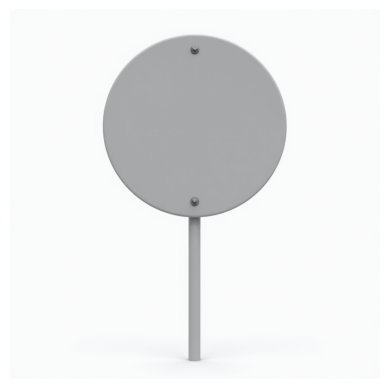

In [6]:
pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    torch_dtype=torch.bfloat16
)
# pipe.enable_model_cpu_offload()
pipe.enable_sequential_cpu_offload()  # instead of enable_model_cpu_offload()

# prompt = "A yellow rubber duck with the left eye replaced by a googlie eye, white background, centered, 3D render"
# prompt = "Back of the roadside sign is orange denoting construction ahead, white background, centered, 3D render"
# prompt = "Back of the roadside sign is green denoting bear in area, white background, centered, 3D render"
prompt = "Back of the roadside sign is nothing and all grey, white background, centered, 3D render"

image = pipe(
    prompt,
    num_inference_steps=50,
    guidance_scale=3.5,
    height=1024,
    width=1024,
).images[0]

plt.imshow(image)
plt.axis("off")

In [7]:
image.save(f"{prompt}.png")